# Drawdown

- worst case scenario of investment; buying high and selling low.
- a strategy with a high max drawdown would indicate a higher risk level, whereas a strategy with a low max drawdown would indicate lower risk.
- **sensitive to outliers!**
- not a sure-fire metric to use when backtesting a trading strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from utils.metrics import Metrics as m
from utils.read_prices import *

In [2]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


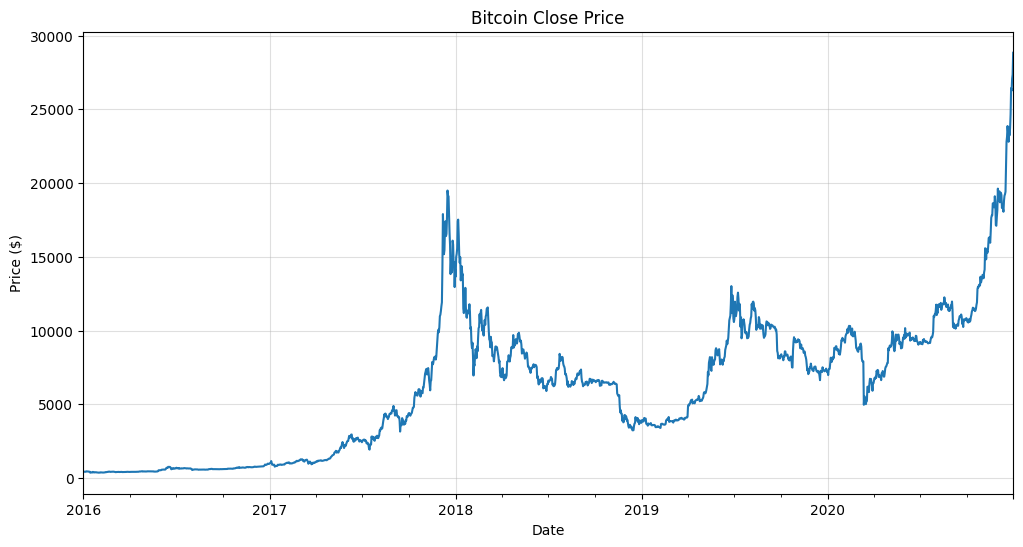

In [3]:
df['Close'].plot(kind='line',
                 title='Bitcoin Close Price',
                 figsize=(12,6),
                 ylabel='Price ($)')

plt.grid(alpha=.4)
plt.show()

In [4]:
df_ = df.loc['2018-01-01': '2019-12-31']
df_.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000,1.33,0.964737,-0.035900
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192,1.42,1.097011,0.092589
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160,1.42,1.014611,0.014505
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744,1.42,1.026196,0.025858
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072,1.42,1.117333,0.110945


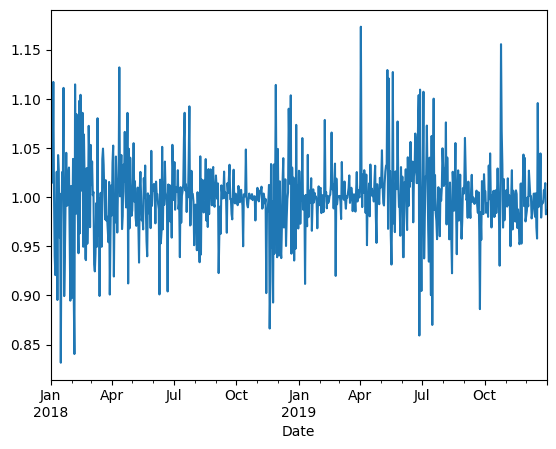

In [5]:
df_['returns'].plot(kind='line')
plt.show()

In [6]:
initial_wealth = 5000

wealth_index_series = initial_wealth * (df_['returns']).cumprod()
wealth_index_series.loc['2018-01-01'] = initial_wealth ## set first value to initial investment

wealth_index_series

Date
2018-01-01    5000.000000
2018-01-02    5291.634595
2018-01-03    5368.949585
2018-01-04    5509.592751
2018-01-05    6156.049391
                 ...     
2019-12-27    2574.838298
2019-12-28    2584.693154
2019-12-29    2621.659683
2019-12-30    2575.864950
2019-12-31    2540.758569
Name: returns, Length: 730, dtype: float64

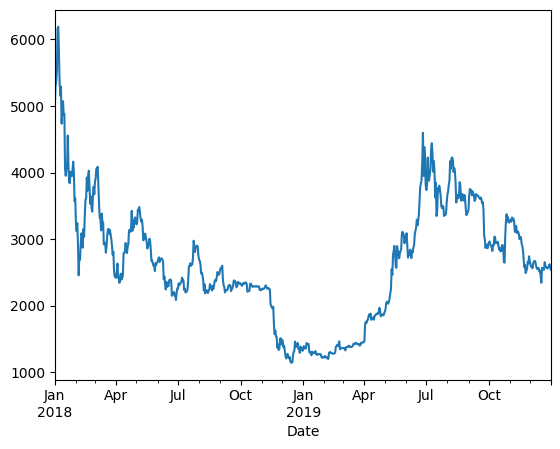

In [7]:
wealth_index_series.plot(kind='line')
plt.show()

In [8]:
terminal_return = m.terminal_return(df_['log_returns'])
print(terminal_return)

5000 * (terminal_return)

-0.4918482861040242


-2459.241430520121

In [9]:
prior_peak = wealth_index_series.cummax() ## peak cumulative price
prior_peak

Date
2018-01-01    5000.000000
2018-01-02    5291.634595
2018-01-03    5368.949585
2018-01-04    5509.592751
2018-01-05    6156.049391
                 ...     
2019-12-27    6190.486111
2019-12-28    6190.486111
2019-12-29    6190.486111
2019-12-30    6190.486111
2019-12-31    6190.486111
Name: returns, Length: 730, dtype: float64

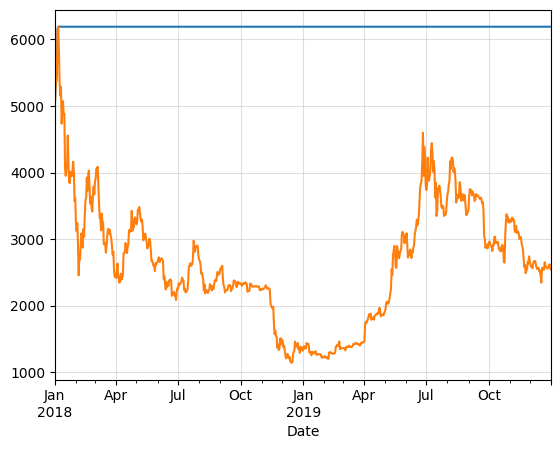

In [10]:
prior_peak.plot(kind='line')
wealth_index_series.plot(kind="line")
plt.grid(alpha=.4)
plt.show()

In [11]:
drawdown = (wealth_index_series - prior_peak) / prior_peak

drawdown

Date
2018-01-01    0.000000
2018-01-02    0.000000
2018-01-03    0.000000
2018-01-04    0.000000
2018-01-05    0.000000
                ...   
2019-12-27   -0.584065
2019-12-28   -0.582473
2019-12-29   -0.576502
2019-12-30   -0.583899
2019-12-31   -0.589570
Name: returns, Length: 730, dtype: float64

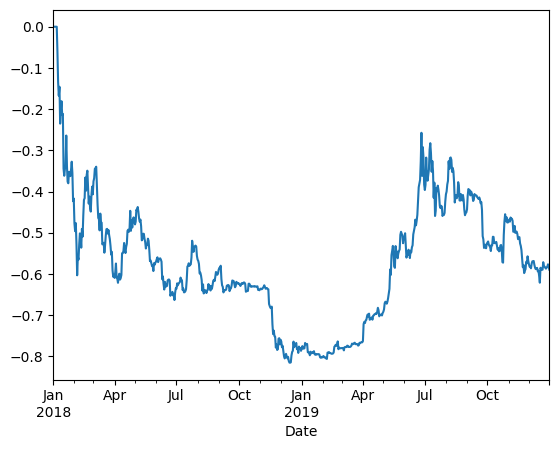

In [12]:
drawdown.plot(kind='line')
plt.show()

In [13]:
drawdown.min()

np.float64(-0.8153271113852912)

In [14]:
wealth_index_series.max()*drawdown.min()

np.float64(-5047.27115895706)

In [15]:
drawdown.idxmin()

Timestamp('2018-12-15 00:00:00')

In [16]:
drawdown_2018 = m.drawdown(df_['returns'])
drawdown_2018

,Wealth Index,Prior Peaks,Drawdown
Date,,,
2018-01-01,0.964737,0.964737,0.000000
2018-01-02,1.058327,1.058327,0.000000
2018-01-03,1.073790,1.073790,0.000000
2018-01-04,1.101919,1.101919,0.000000
2018-01-05,1.231210,1.231210,0.000000
...,...,...,...
2019-12-27,0.514968,1.238097,-0.584065
2019-12-28,0.516939,1.238097,-0.582473
2019-12-29,0.524332,1.238097,-0.576502


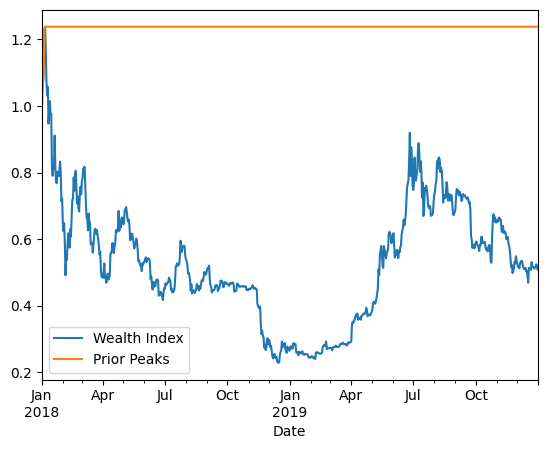

In [17]:
drawdown_2018[['Wealth Index', 'Prior Peaks']].plot(kind='line')
plt.show()

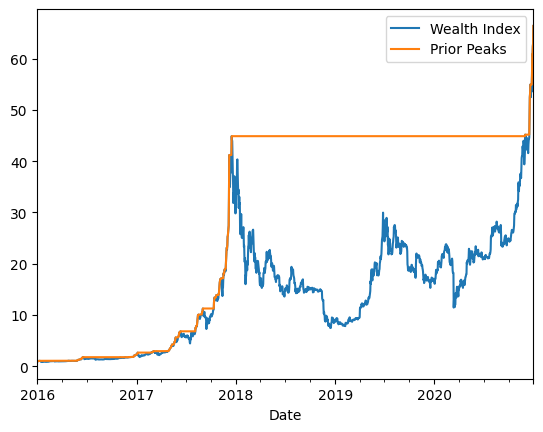

In [26]:
## whole dataset
m.drawdown(df['returns'])[['Wealth Index', 'Prior Peaks']].plot(kind='line')
plt.show()

In [27]:
whole_drawdown = m.drawdown(df['returns'], init_investment=5000)
whole_drawdown

,Wealth Index,Prior Peaks,Drawdown
Date,,,
2016-01-01,NaN,NaN,NaN
2016-01-02,4989.685051,4989.685051,0.000000
2016-01-03,4950.233824,4989.685051,-0.007907
2016-01-04,4985.690604,4989.685051,-0.000801
2016-01-05,4972.670533,4989.685051,-0.003410
...,...,...,...
2020-12-26,304339.934277,304339.934277,0.000000
2020-12-27,302443.442386,304339.934277,-0.006231
2020-12-28,311797.000293,311797.000293,0.000000


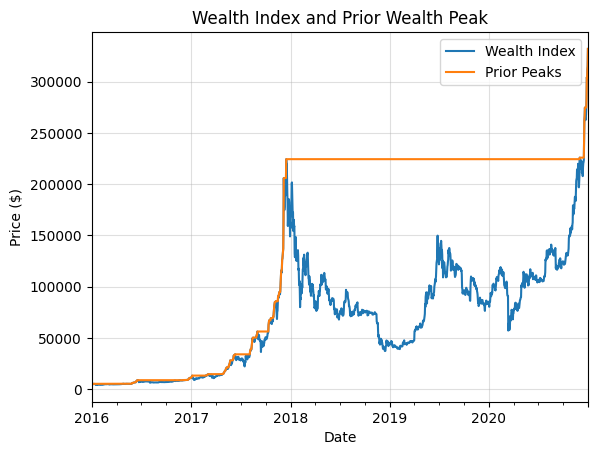

In [28]:
whole_drawdown[['Wealth Index', 'Prior Peaks']].plot(kind='line',
title='Wealth Index and Prior Wealth Peak',
ylabel='Price ($)')

plt.grid(alpha=.4)
plt.show()

In [30]:
whole_drawdown["Drawdown"].min(), m.drawdown(df['returns'])["Drawdown"].min()

(np.float64(-0.8339900882218975), np.float64(-0.8339900882218975))

In [32]:
m.drawdown(df['returns'])["Drawdown"].idxmin()

Timestamp('2018-12-15 00:00:00')

In [23]:
whole_drawdown['Drawdown'].idxmax()

Timestamp('2016-01-02 00:00:00')

In [24]:
temp = m.drawdown(df['log_returns'])["Drawdown"] == 0

periods = (temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime())

periods[12:15]

array([datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=1)], dtype=object)

In [25]:
periods.max()

datetime.timedelta(days=1)